# 06 Final Insights and Recommendations

This notebook summarizes the main findings from the Online Retail analysis project.

The goal is to turn the analysis from previous notebooks into clear business insights and recommendations.

This final notebook covers:
- Overall sales performance
- Product performance
- Country and market insights
- Customer behavior
- RFM customer segments
- Market basket findings
- Business recommendations
- Project limitations
- Suggested next steps

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/cleaned/online_retail_cleaned.csv",
    dtype={
        "InvoiceNo": "string",
        "StockCode": "string",
        "CustomerID": "Int64"
    },
    parse_dates=["InvoiceDate"]
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,HasCustomerID,ProductDescription,TotalPrice,IsHighValueOutlier,IsNonProduct
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,True,WHITE HANGING HEART T-LIGHT HOLDER,15.30,False,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,True,WHITE METAL LANTERN,20.34,False,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,True,CREAM CUPID HEARTS COAT HANGER,22.00,False,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,True,KNITTED UNION FLAG HOT WATER BOTTLE,20.34,False,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,True,RED WOOLLY HOTTIE WHITE HEART.,20.34,False,False


In [5]:
# Recreate missing customer analysis report tables

customer_df = df[df["CustomerID"].notna()].copy()

customer_summary = customer_df.groupby("CustomerID").agg(
    TotalRevenue=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    InvoiceCount=("InvoiceNo", "nunique"),
    FirstPurchaseDate=("InvoiceDate", "min"),
    LastPurchaseDate=("InvoiceDate", "max")
).reset_index()

customer_summary["AverageOrderValue"] = (
    customer_summary["TotalRevenue"] / customer_summary["InvoiceCount"]
)

snapshot_date = customer_df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = customer_summary[[
    "CustomerID",
    "TotalRevenue",
    "InvoiceCount",
    "LastPurchaseDate"
]].copy()

rfm["Recency"] = (snapshot_date - rfm["LastPurchaseDate"]).dt.days
rfm["Frequency"] = rfm["InvoiceCount"]
rfm["Monetary"] = rfm["TotalRevenue"]

rfm = rfm[[
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary"
]]

rfm["RScore"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["FScore"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["MScore"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["RFMScore"] = rfm["RScore"] + rfm["FScore"] + rfm["MScore"]

def segment_customer(row):
    if row["RFMScore"] >= 13:
        return "Best Customers"
    elif row["RScore"] >= 4 and row["FScore"] >= 4:
        return "Loyal Customers"
    elif row["RScore"] >= 4 and row["FScore"] <= 2:
        return "New or Recent Customers"
    elif row["RScore"] <= 2 and row["FScore"] >= 4:
        return "At Risk Customers"
    elif row["RScore"] <= 2 and row["MScore"] >= 4:
        return "Past High-Value Customers"
    elif row["RFMScore"] <= 5:
        return "Low Value Customers"
    else:
        return "Regular Customers"

rfm["CustomerSegment"] = rfm.apply(segment_customer, axis=1)

customer_segment_summary = rfm.groupby("CustomerSegment").agg(
    CustomerCount=("CustomerID", "count"),
    AverageRecency=("Recency", "mean"),
    AverageFrequency=("Frequency", "mean"),
    AverageMonetary=("Monetary", "mean"),
    TotalRevenue=("Monetary", "sum")
).reset_index()

customer_segment_summary["CustomerShare"] = (
    customer_segment_summary["CustomerCount"] / customer_segment_summary["CustomerCount"].sum()
) * 100

customer_segment_summary["RevenueShare"] = (
    customer_segment_summary["TotalRevenue"] / customer_segment_summary["TotalRevenue"].sum()
) * 100

customer_segment_summary = customer_segment_summary.sort_values(
    by="TotalRevenue",
    ascending=False
)

customer_summary.to_csv(reports_path / "customer_summary.csv", index=False)
rfm.to_csv(reports_path / "rfm_customer_segments.csv", index=False)
customer_segment_summary.to_csv(reports_path / "customer_segment_summary.csv", index=False)

print("Missing customer report tables recreated and exported.")

Missing customer report tables recreated and exported.


In [6]:
from pathlib import Path

reports_path = Path("../reports")

print("Reports folder exists:", reports_path.exists())

for file in reports_path.glob("*.csv"):
    print(file.name)

Reports folder exists: True
country_revenue.csv
customer_segment_summary.csv
customer_summary.csv
invoice_summary.csv
monthly_revenue.csv
non_uk_country_revenue.csv
product_pair_associations.csv
product_performance.csv
rfm_customer_segments.csv
strong_product_associations.csv


In [7]:
total_revenue = df["TotalPrice"].sum()
total_quantity = df["Quantity"].sum()
unique_invoices = df["InvoiceNo"].nunique()
unique_products = df["StockCode"].nunique()
unique_customers = df["CustomerID"].nunique()
countries = df["Country"].nunique()

summary_kpis = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Quantity Sold",
        "Unique Invoices",
        "Unique Products",
        "Unique Customers",
        "Countries"
    ],
    "Value": [
        round(total_revenue, 2),
        total_quantity,
        unique_invoices,
        unique_products,
        unique_customers,
        countries
    ]
})

summary_kpis

,Metric,Value
0,Total Revenue,10642110.8
1,Total Quantity Sold,5572420.0
2,Unique Invoices,19960.0
3,Unique Products,3922.0
4,Unique Customers,4338.0
5,Countries,38.0


In [8]:
product_performance.head(10)

,StockCode,ProductDescription,TotalRevenue,TotalQuantity,InvoiceCount,RevenueRank,QuantityRank,InvoiceRank
0,10002,INFLATABLE POLITICAL GLOBE,759.89,860,71,1861.0,1363.5,1876.0
1,10080,GROOVY CACTUS INFLATABLE,119.09,303,22,2971.0,2090.0,2761.5
2,10120,DOGGY RUBBER,40.32,192,29,3381.0,2366.5,2577.0
3,10123C,HEARTS WRAPPING TAPE,3.25,5,3,3867.0,3653.0,3589.0
4,10124A,SPOTS ON RED BOOKCOVER TAPE,6.72,16,5,3784.5,3361.5,3437.0
5,10124G,ARMY CAMO BOOKCOVER TAPE,7.14,17,4,3778.0,3344.0,3506.0
6,10125,MINI FUNKY DESIGN TAPES,993.99,1295,91,1639.0,1037.5,1618.0
7,10133,COLOURING PENCILS BROWN TUBE,1539.60,2856,196,1281.0,484.0,835.0
8,10135,COLOURING PENCILS BROWN TUBE,2204.89,2229,175,985.0,638.0,924.0
9,11001,ASSTD DESIGN RACING CAR PEN,2389.44,1615,113,930.0,883.0,1387.0


In [9]:
customer_segment_summary

,CustomerSegment,CustomerCount,AverageRecency,AverageFrequency,AverageMonetary,TotalRevenue,CustomerShare,RevenueShare
1,Best Customers,929,14.518837,11.779333,6705.386911,6229304.440,21.415399,70.092922
6,Regular Customers,1476,76.591463,2.316396,765.407163,1129740.973,34.024896,12.711989
5,Past High-Value Customers,171,160.970760,1.976608,2696.995795,461186.281,3.941909,5.189326
0,At Risk Customers,285,134.792982,4.887719,1590.721754,453355.700,6.569848,5.101216
3,Loyal Customers,282,18.148936,4.000000,955.051560,269324.540,6.500692,3.030474
2,Low Value Customers,885,223.972881,1.045198,228.313582,202057.520,20.401107,2.273577
4,New or Recent Customers,310,18.096774,1.245161,458.836903,142239.440,7.14615,1.600496


In [12]:
strong_product_associations.head(10)

,ProductA,ProductB,PairCount,ProductACount,ProductBCount,PairSupport,Confidence_A_to_B,Confidence_B_to_A,Lift
0,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,632,1007,755,0.048909,0.627607,0.837086,10.741635
1,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,546,748,905,0.042254,0.729947,0.603315,10.422507
2,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,598,755,1049,0.046278,0.792053,0.570067,9.756824
3,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,767,1007,1049,0.059356,0.761668,0.731173,9.382534
4,CHARLOTTE BAG PINK POLKADOT,STRAWBERRY CHARLOTTE BAG,379,739,720,0.029330,0.512855,0.526389,9.204326
5,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,538,848,896,0.041634,0.634434,0.600446,9.149727
6,CHARLOTTE BAG PINK POLKADOT,RED RETROSPOT CHARLOTTE BAG,522,739,1028,0.040396,0.706360,0.507782,8.878972
7,STRAWBERRY CHARLOTTE BAG,WOODLAND CHARLOTTE BAG,406,720,827,0.031419,0.563889,0.490931,8.810849
8,SET OF 3 BUTTERFLY COOKIE CUTTERS,SET OF 3 HEART COOKIE CUTTERS,311,678,673,0.024067,0.458702,0.462110,8.807352
9,CHARLOTTE BAG SUKI DESIGN,STRAWBERRY CHARLOTTE BAG,415,869,720,0.032116,0.477560,0.576389,8.570883


## Overall Business Performance

The cleaned dataset contains:

- Total revenue: 10,642,110.80
- Total quantity sold: 5,572,420 items
- Unique invoices: 19,960
- Unique products: 3,922
- Unique customers: 4,338
- Countries: 38

This shows that the dataset represents a large retail operation with many products, customers, and international sales activity.

In [13]:
country_revenue.head(10)

,Country,TotalPrice,RevenueShare
0,United Kingdom,9001744.094,84.586078
1,Netherlands,285446.340,2.682234
2,EIRE,283140.520,2.660567
3,Germany,228678.400,2.148807
4,France,209625.370,1.969772
5,Australia,138453.810,1.301000
6,Spain,61558.560,0.578443
7,Switzerland,57067.600,0.536243
8,Belgium,41196.340,0.387107
9,Sweden,38367.830,0.360528


## Country and Market Insights

The United Kingdom is the dominant market in the dataset, contributing the largest share of revenue and transaction activity.

However, earlier analysis showed that non-UK customers had a higher average revenue per customer than UK customers.

This means that while the UK is the core market, international customers may be more valuable on average.

Business implication:
The company should continue focusing on the UK market because of its size, but it should also investigate high-value international markets such as the Netherlands, EIRE, Germany, France, and Australia.

In [14]:
top_products = product_performance.head(10)

top_products

,StockCode,ProductDescription,TotalRevenue,TotalQuantity,InvoiceCount,RevenueRank,QuantityRank,InvoiceRank
0,10002,INFLATABLE POLITICAL GLOBE,759.89,860,71,1861.0,1363.5,1876.0
1,10080,GROOVY CACTUS INFLATABLE,119.09,303,22,2971.0,2090.0,2761.5
2,10120,DOGGY RUBBER,40.32,192,29,3381.0,2366.5,2577.0
3,10123C,HEARTS WRAPPING TAPE,3.25,5,3,3867.0,3653.0,3589.0
4,10124A,SPOTS ON RED BOOKCOVER TAPE,6.72,16,5,3784.5,3361.5,3437.0
5,10124G,ARMY CAMO BOOKCOVER TAPE,7.14,17,4,3778.0,3344.0,3506.0
6,10125,MINI FUNKY DESIGN TAPES,993.99,1295,91,1639.0,1037.5,1618.0
7,10133,COLOURING PENCILS BROWN TUBE,1539.60,2856,196,1281.0,484.0,835.0
8,10135,COLOURING PENCILS BROWN TUBE,2204.89,2229,175,985.0,638.0,924.0
9,11001,ASSTD DESIGN RACING CAR PEN,2389.44,1615,113,930.0,883.0,1387.0


## Product Performance Insights

Product performance varies depending on the metric used.

Some products generate high total revenue, while others are purchased frequently across many invoices.

A key finding from the product analysis was that some products had very high revenue because of large bulk purchases. Therefore, product performance should not be judged by revenue alone.

Better product evaluation should compare:
- Total revenue
- Total quantity sold
- Invoice count
- Consistency across orders

Business implication:
The company should prioritize products that perform well across multiple metrics, not only products with one unusually large order.

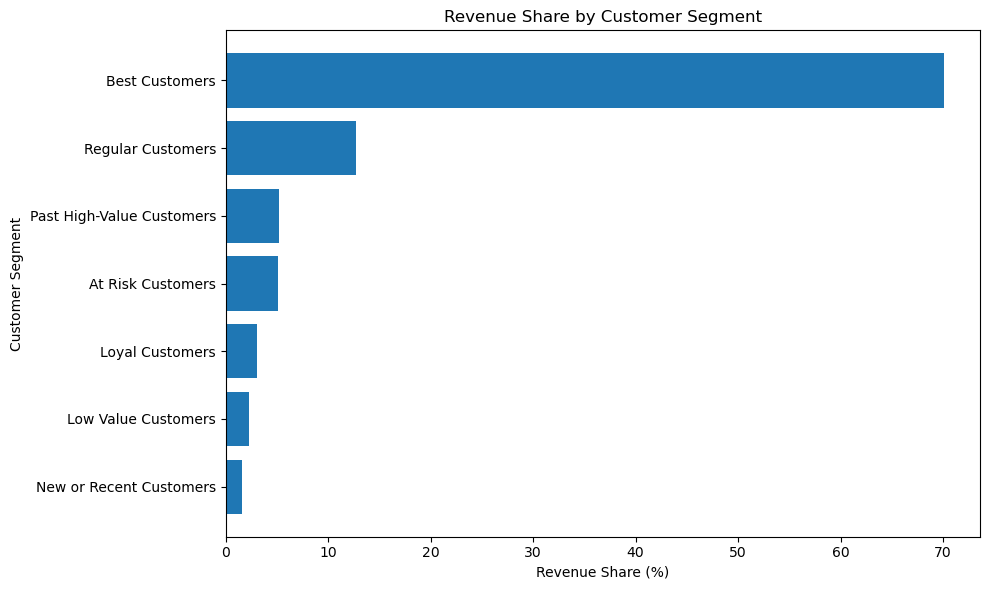

In [15]:
customer_segment_summary_sorted = customer_segment_summary.sort_values(
    by="RevenueShare",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(
    customer_segment_summary_sorted["CustomerSegment"],
    customer_segment_summary_sorted["RevenueShare"]
)
plt.title("Revenue Share by Customer Segment")
plt.xlabel("Revenue Share (%)")
plt.ylabel("Customer Segment")
plt.tight_layout()
plt.show()

## Customer Behavior Insights

Customer revenue is highly concentrated.

The most important segment is Best Customers:
- They represent about 21.42% of identified customers
- They generate about 70.09% of customer revenue
- They purchase recently, frequently, and spend more on average

Low Value Customers represent about 20.40% of customers but only generate about 2.27% of revenue.

Business implication:
The company should focus heavily on customer retention. Losing a small number of high-value customers could have a large impact on revenue.

In [16]:
strong_product_associations.head(10)

,ProductA,ProductB,PairCount,ProductACount,ProductBCount,PairSupport,Confidence_A_to_B,Confidence_B_to_A,Lift
0,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,632,1007,755,0.048909,0.627607,0.837086,10.741635
1,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,546,748,905,0.042254,0.729947,0.603315,10.422507
2,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,598,755,1049,0.046278,0.792053,0.570067,9.756824
3,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,767,1007,1049,0.059356,0.761668,0.731173,9.382534
4,CHARLOTTE BAG PINK POLKADOT,STRAWBERRY CHARLOTTE BAG,379,739,720,0.029330,0.512855,0.526389,9.204326
5,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,538,848,896,0.041634,0.634434,0.600446,9.149727
6,CHARLOTTE BAG PINK POLKADOT,RED RETROSPOT CHARLOTTE BAG,522,739,1028,0.040396,0.706360,0.507782,8.878972
7,STRAWBERRY CHARLOTTE BAG,WOODLAND CHARLOTTE BAG,406,720,827,0.031419,0.563889,0.490931,8.810849
8,SET OF 3 BUTTERFLY COOKIE CUTTERS,SET OF 3 HEART COOKIE CUTTERS,311,678,673,0.024067,0.458702,0.462110,8.807352
9,CHARLOTTE BAG SUKI DESIGN,STRAWBERRY CHARLOTTE BAG,415,869,720,0.032116,0.477560,0.576389,8.570883


In [17]:
strong_product_associations = pd.read_csv(reports_path / "strong_product_associations.csv")
strong_product_associations.head(10)

,ProductA,ProductB,PairCount,ProductACount,ProductBCount,PairSupport,Confidence_A_to_B,Confidence_B_to_A,Lift
0,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,632,1007,755,0.048909,0.627607,0.837086,10.741635
1,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,546,748,905,0.042254,0.729947,0.603315,10.422507
2,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,598,755,1049,0.046278,0.792053,0.570067,9.756824
3,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,767,1007,1049,0.059356,0.761668,0.731173,9.382534
4,CHARLOTTE BAG PINK POLKADOT,STRAWBERRY CHARLOTTE BAG,379,739,720,0.029330,0.512855,0.526389,9.204326
5,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,538,848,896,0.041634,0.634434,0.600446,9.149727
6,CHARLOTTE BAG PINK POLKADOT,RED RETROSPOT CHARLOTTE BAG,522,739,1028,0.040396,0.706360,0.507782,8.878972
7,STRAWBERRY CHARLOTTE BAG,WOODLAND CHARLOTTE BAG,406,720,827,0.031419,0.563889,0.490931,8.810849
8,SET OF 3 BUTTERFLY COOKIE CUTTERS,SET OF 3 HEART COOKIE CUTTERS,311,678,673,0.024067,0.458702,0.462110,8.807352
9,CHARLOTTE BAG SUKI DESIGN,STRAWBERRY CHARLOTTE BAG,415,869,720,0.032116,0.477560,0.576389,8.570883


## Market Basket Insights

The market basket analysis showed that many products are frequently purchased with similar or related items.

Common product groups included:
- Jumbo bags
- Lunch bags
- Regency teacups and saucers
- Alarm clocks
- Christmas paper chain kits
- Gardeners kneeling pads

The strongest product pair by co-purchase count was:
- JUMBO BAG PINK POLKADOT
- JUMBO BAG RED RETROSPOT

This pair appeared together in 825 invoices.

Business implication:
The company could use these product relationships for product bundles, cross-selling recommendations, and related-product promotions.

## Business Recommendations

Based on the analysis, the following business recommendations can be made:

1. Retain high-value customers  
Best Customers represent about 21.42% of customers but generate about 70.09% of customer revenue. The company should focus on loyalty programs, personalized offers, and early access promotions for this group.

2. Re-engage at-risk and past high-value customers  
At Risk Customers and Past High-Value Customers previously generated meaningful revenue but have not purchased recently. These customers could be targeted with win-back campaigns.

3. Promote product bundles  
Market basket analysis showed that customers often buy related products together, especially within product families such as jumbo bags, lunch bags, teacups, alarm clocks, and Christmas products. These products could be promoted as bundles or recommended together.

4. Investigate international markets  
The UK is the largest market, but non-UK customers had higher average revenue per customer. The company should investigate high-value international markets such as the Netherlands, EIRE, Germany, France, and Australia.

5. Evaluate products using multiple metrics  
Some products generated high revenue from only one or a few large orders. Product decisions should consider revenue, quantity sold, invoice count, and consistency across orders.

## Project Limitations

This project has some limitations:

- The dataset covers only transactions from December 2010 to December 2011.
- December 2011 is incomplete because the data ends on December 9.
- CustomerID is missing for many rows, so customer analysis only includes identified customers.
- Canceled invoices and negative quantities were removed to focus on completed positive sales.
- Market basket analysis focused on the top 100 most frequent products to keep the analysis efficient and understandable.
- The market basket section used a simple product-pair approach instead of a full Apriori or FP-Growth model.
- The dataset does not include customer demographics, marketing channels, profit margins, or inventory costs.

## Suggested Next Steps

Future improvements could include:

- Building a Power BI dashboard to present the main findings visually.
- Applying Apriori or FP-Growth for deeper association rule mining.
- Investigating high-value outlier transactions in more detail.
- Comparing UK and non-UK customers more deeply.
- Creating customer retention strategies based on RFM segments.
- Adding dashboard screenshots and a clear README file before uploading the project to GitHub.

## Final Conclusion

This project analyzed the Online Retail dataset to understand sales trends, customer behavior, product performance, country-level performance, and product associations.

The main finding is that revenue is highly concentrated. A small group of high-value customers generates most of the revenue, while many customers contribute relatively little. The UK is the largest market, but international customers appear valuable on average. Product analysis showed that revenue alone is not enough to judge product performance because some products are affected by large bulk orders.

The market basket analysis showed that customers often buy related products together, especially products from the same product family. These findings can support product bundling, cross-selling, customer retention, and international market strategy.

Overall, this project demonstrates a complete data analysis workflow, from data understanding and cleaning to exploratory analysis, customer segmentation, market basket analysis, and business recommendations.